# Supplementary Figure 5 panel G - figure

In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
# --- Manuscript plotting style ---
axis_label_font_size = 7
tick_label_font_size = 6
anno_font_size = 5
plt.rcParams.update({
    'font.size': axis_label_font_size,
    'axes.titlesize': axis_label_font_size,
    'axes.labelsize': axis_label_font_size,
    'xtick.labelsize': tick_label_font_size,
    'ytick.labelsize': tick_label_font_size,
    'legend.fontsize': tick_label_font_size,
    'legend.title_fontsize': axis_label_font_size,
})

# --- Input path ---
INTERMEDIATE_DIR = 'intermediate_data/'

# --- Output path ---
FIGURE_DIR = 'figures/'
os.makedirs(FIGURE_DIR, exist_ok=True)

# --- Analysis configuration ---
LOCUS_OF_INTEREST = 'DRB1'
SEROTYPE_OF_INTEREST = 'DRB1*15'
ALLELES_OF_INTEREST = ['DRB1*15:01', 'DRB1*15:02', 'DRB1*15:03']
TOX_TYPE = 'adrenal_insufficiency'
AE_GRADE = 0  # 0 = Grade 1+


In [3]:
def assign_allele_dosage(df, allele, locus):
    """Compute each patient's dosage (0/1/2 copies) of `allele` (one or
    more IMGT allele names) from their two genotype calls at `locus`.
    Factored out of Figure 5 main panel G's `plot_cif_by_allele_dosage` so
    this panel can compute dosage without needing any of that function's
    time-to-event / CIF-fitting logic."""
    if isinstance(allele, str):
        allele_set = {allele.strip().upper()}
    else:
        allele_set = {a.strip().upper() for a in allele}

    a1 = f'{locus}_1'
    a2 = f'{locus}_2'

    cols = [a1, a2, 'ancestry']
    dd = df[cols].dropna().copy()

    dd['allele_dosage'] = (
        dd[a1].astype(str).str.strip().str.upper().isin(allele_set).astype(int) +
        dd[a2].astype(str).str.strip().str.upper().isin(allele_set).astype(int)
    )
    return dd


def plot_ancestry_by_dosage(dd, valid_groups, allele_label, locus, plot_out_dir_pos, tox_type, ae_grade,
                             serotype_of_interest, color_map=None):
    """Stacked bar chart of DRB1*15 dosage composition (0/1/2 copies)
    within each genetic ancestry group, with allele-frequency annotations.
    Identical to Figure 5 main panel G's `plot_ancestry_by_dosage`
    (originally called as a companion plot alongside that panel's CIF
    figure); here it is this panel's only plot."""
    dd_valid = dd[dd['allele_dosage'].isin(valid_groups)]

    af_by_ancestry = (
        dd_valid.groupby('ancestry')
        .agg(total_copies=('allele_dosage', 'sum'), n=('allele_dosage', 'size'))
        .assign(allele_freq=lambda x: x['total_copies'] / (2 * x['n']))
        .sort_values('ancestry')
    )

    dosage_counts = (
        dd_valid.groupby(['ancestry', 'allele_dosage'])
        .size().unstack(fill_value=0).sort_index()
    )
    dosage_order = [d for d in [0, 1, 2] if d in dosage_counts.columns]
    dosage_counts = dosage_counts[dosage_order]
    dosage_props = dosage_counts.div(dosage_counts.sum(axis=1), axis=0)

    ancestries = dosage_props.index.tolist()
    x = np.arange(len(ancestries))

    fig, ax = plt.subplots(figsize=(4, 3))

    dosage_color_map = {0: '#c6dbef', 1: '#6baed6', 2: '#08519c'}

    bottoms = np.zeros(len(ancestries))
    for dosage in reversed(dosage_order):
        vals = dosage_props[dosage].values
        ax.bar(x, vals, bottom=bottoms, label=f'Dosage {dosage}',
               color=dosage_color_map[dosage], width=0.6, linewidth=1.2, edgecolor='white')
        bottoms += vals

    for i, anc in enumerate(ancestries):
        af = af_by_ancestry.loc[anc, 'allele_freq']
        n = af_by_ancestry.loc[anc, 'n']
        ax.text(i, 1.03, f'AF {af:.3f}\nn={n}', ha='center', va='bottom', fontsize=anno_font_size)

    ax.set_xticks(x)
    ax.set_xticklabels(ancestries, fontsize=tick_label_font_size)
    ax.set_ylabel('Proportion of samples', fontsize=axis_label_font_size)
    ax.set_xlabel('Genetic ancestry', fontsize=axis_label_font_size)
    ax.set_ylim(0, 1.15)
    ax.set_yticks(np.arange(0, 1.01, 0.2))

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    ax.tick_params(axis='both', which='both', width=0.5, length=4, bottom=True, left=True, top=False, right=False)

    handles, labels = ax.get_legend_handles_labels()
    handles, labels = handles[::-1], labels[::-1]
    legend = ax.legend(
        handles, labels, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.15),
        frameon=False, fontsize=tick_label_font_size,
    )
    legend.set_title(serotype_of_interest, prop={'size': axis_label_font_size})

    plt.tight_layout()

    for ext in ('pdf', 'png'):
        plt.savefig(
            os.path.join(plot_out_dir_pos, f'fig5s_panel_g_{locus}_{serotype_of_interest}_{tox_type}_grade{ae_grade}_ancestry.{ext}'),
            dpi=300, bbox_inches='tight', bbox_extra_artists=(legend,),
        )


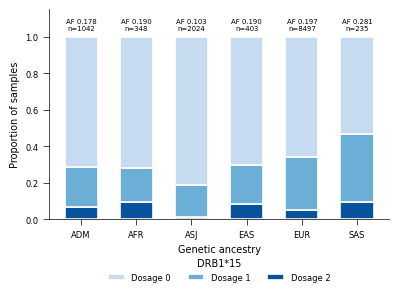

In [4]:
cohort_path = os.path.join(INTERMEDIATE_DIR, f'fig5s_panel_g_cohort_{TOX_TYPE}_grade{AE_GRADE}.csv')
df_plot = pd.read_csv(cohort_path)

dd = assign_allele_dosage(df_plot, allele=ALLELES_OF_INTEREST, locus=LOCUS_OF_INTEREST)
valid_groups = sorted(dd['allele_dosage'].unique())
allele_label = '/'.join(sorted({a.strip().upper() for a in ALLELES_OF_INTEREST}))

plot_out_dir_pos = FIGURE_DIR
os.makedirs(plot_out_dir_pos, exist_ok=True)

plot_ancestry_by_dosage(
    dd=dd,
    valid_groups=valid_groups,
    allele_label=allele_label,
    locus=LOCUS_OF_INTEREST,
    plot_out_dir_pos=plot_out_dir_pos,
    tox_type=TOX_TYPE,
    ae_grade=AE_GRADE,
    serotype_of_interest=SEROTYPE_OF_INTEREST,
)
